In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd


In [ ]:
file_path = '/content/drive/My Drive/macroeconomic shocks and impact/mfmfs/india_macro_data.csv'

# 3. Load the CSV into a DataFrame and set 'Quater' as the index
df = pd.read_csv(file_path, index_col='Quater')

# 4. View the first few rows (optional)
df.head(45)

,Quaterly YoY real gdp change,adjusted quaterly repo rate,Combined QuaterlyYoY inflation,Rural QuaterlyYoY inflation,Urban Quaterly YoY inflation,Real Private Sector Final Consumption Expenditure for India(Quaterly YoY change),Real General Government Final Consumption Expenditure for India(Quaterly YoY change),Real Final Consumption Expenditure for India(Quaterly YoY change),quaterly YoY returns of nifty 500 closing index,Quaterly M0 YoY growth rate,Quaterly M3 YoY growth rate,Total Assets Quaterly YoY growth rate,Quaterly Fiscal Deficit (% of GDP)per Quarter,Quaterly Fiscal Deficit (% of GDP)
Quater,,,,,,,,,,,,,,
2014Q1,5.343,8.000,8.244,8.174,8.289,8.282,-13.676,4.630,17.721,14.381,13.440,12.077,1.26,1.26
2014Q2,8.024,8.000,7.860,8.035,7.688,7.249,2.345,6.411,36.873,9.738,11.824,8.830,1.89,1.89
2014Q3,8.704,8.000,6.682,7.163,6.140,8.744,10.063,8.977,46.075,9.594,12.438,4.627,0.89,0.89
2014Q4,5.923,8.000,4.054,4.023,4.151,2.129,28.956,5.271,37.820,9.438,10.711,3.608,0.97,0.97
2015Q1,7.112,7.711,5.272,5.601,4.887,7.828,-7.200,5.766,33.557,11.295,10.852,8.024,0.35,0.35
2015Q2,7.593,7.420,5.091,5.624,4.441,7.110,4.767,6.726,11.710,10.216,10.611,11.099,2.10,2.10
2015Q3,8.034,7.250,3.948,4.624,3.101,7.101,9.012,7.443,3.591,12.326,10.659,13.973,0.60,0.60
2015Q4,7.197,7.082,5.340,5.933,4.573,8.565,8.265,8.522,-0.722,14.284,10.711,16.105,0.80,0.80
2016Q1,9.089,6.750,5.260,6.078,4.351,8.795,7.789,8.674,-7.538,13.082,10.118,15.595,0.40,0.40


In [ ]:
df.shape

(44, 14)

In [ ]:
# Install necessary libraries
!pip install statsmodels matplotlib pandas numpy scipy

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
from scipy.stats import ortho_group
from scipy.linalg import cholesky
from google.colab import files

In [ ]:
print(df.index)

Index(['2014Q1', '2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3',
       '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2',
       '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1',
       '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4',
       '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3',
       '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2',
       '2024Q3', '2024Q4'],
      dtype='object', name='Quater')


In [ ]:
print(df.columns)

Index(['Quaterly YoY real gdp change', 'adjusted quaterly repo rate',
       'Combined QuaterlyYoY inflation', 'Rural QuaterlyYoY inflation',
       'Urban Quaterly YoY inflation',
       'Real Private Sector Final Consumption Expenditure for India(Quaterly YoY change)',
       'Real General Government Final Consumption Expenditure for India(Quaterly YoY change) ',
       'Real Final Consumption Expenditure for India(Quaterly YoY change) ',
       'quaterly YoY returns of nifty 500 closing index',
       'Quaterly M0 YoY growth rate', 'Quaterly M3 YoY growth rate',
       'Total Assets Quaterly YoY growth rate',
       'Quaterly Fiscal Deficit (% of GDP)per Quarter',
       'Quaterly Fiscal Deficit (% of GDP)'],
      dtype='object')


In [ ]:
df.drop(columns=['Rural QuaterlyYoY inflation'], inplace=True)

In [ ]:
df.drop(columns=['Urban Quaterly YoY inflation'], inplace=True)

In [ ]:
df.drop(columns=['Real General Government Final Consumption Expenditure for India(Quaterly YoY change) '], inplace=True)

In [ ]:
df.drop(columns=['Real Final Consumption Expenditure for India(Quaterly YoY change) '], inplace=True)

In [ ]:
df.drop(columns=['Quaterly Fiscal Deficit (% of GDP)'], inplace=True)

In [ ]:
# Correct the quarter string to Period
df.index = pd.PeriodIndex(df.index, freq='Q')

# Rename all columns correctly (fixing spelling and naming for simplicity)
df = df.rename(columns={
    'Quaterly YoY real gdp change': 'gdp_growth',
    'adjusted quaterly repo rate': 'repo_rate',
    'Combined QuaterlyYoY inflation': 'inflation',
    'Real Private Sector Final Consumption Expenditure for India(Quaterly YoY change)': 'consumption_growth',
    'quaterly YoY returns of nifty 500 closing index': 'nifty_returns',
    'Quaterly Fiscal Deficit (% of GDP)per Quarter': 'fiscal_deficit',
    'Quaterly M3 YoY growth rate': 'm3_growth',
    'Quaterly M0 YoY growth rate': 'm0_growth',
    'Total Assets Quaterly YoY growth rate': 'assets_growth'
})

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')


In [ ]:
print(df.columns)

Index(['gdp_growth', 'repo_rate', 'inflation', 'consumption_growth',
       'nifty_returns', 'm0_growth', 'm3_growth', 'assets_growth',
       'fiscal_deficit'],
      dtype='object')


In [ ]:
df.head(45)

,gdp_growth,repo_rate,inflation,consumption_growth,nifty_returns,m0_growth,m3_growth,assets_growth,fiscal_deficit
Quater,,,,,,,,,
2014Q1,5.343,8.000,8.244,8.282,17.721,14.381,13.440,12.077,1.26
2014Q2,8.024,8.000,7.860,7.249,36.873,9.738,11.824,8.830,1.89
2014Q3,8.704,8.000,6.682,8.744,46.075,9.594,12.438,4.627,0.89
2014Q4,5.923,8.000,4.054,2.129,37.820,9.438,10.711,3.608,0.97
2015Q1,7.112,7.711,5.272,7.828,33.557,11.295,10.852,8.024,0.35
2015Q2,7.593,7.420,5.091,7.110,11.710,10.216,10.611,11.099,2.10
2015Q3,8.034,7.250,3.948,7.101,3.591,12.326,10.659,13.973,0.60
2015Q4,7.197,7.082,5.340,8.565,-0.722,14.284,10.711,16.105,0.80
2016Q1,9.089,6.750,5.260,8.795,-7.538,13.082,10.118,15.595,0.40


In [ ]:
def adf_summary(series, sig_level=0.10, autolag='AIC'):
    """
    Run ADF test on a 1D pandas Series and return a dict of statistics.
    """
    result = adfuller(series, autolag=autolag)
    stat, pval, lags, nobs, crit_vals, icbest = result
    return {
        'ADF Statistic':    stat,
        'p-value':          pval,
        'Lags Used':        lags,
        'Observations':     nobs,
        'CritVal 1%':       crit_vals['1%'],
        'CritVal 5%':       crit_vals['5%'],
        'CritVal 10%':      crit_vals['10%'],
        'Stationary (10%)': 'Yes' if pval < sig_level else 'No'
    }

# ————————————————————————————————
# Step 1: Loop over all columns and collect results
unit_root_results = []

for col in df.columns:
    series = df[col].dropna()
    if len(series) < 10:
        # not enough data to run ADF
        unit_root_results.append({
            'Variable':     col,
            'ADF Statistic': None,
            'p-value':       None,
            'Lags Used':     None,
            'Observations':  len(series),
            'CritVal 1%':    None,
            'CritVal 5%':    None,
            'CritVal 10%':   None,
            'Stationary (10%)': 'Insufficient data'
        })
    else:
        stats = adf_summary(series)
        stats['Variable'] = col
        unit_root_results.append(stats)

# ————————————————————————————————
# Step 2: Build DataFrame, display & save
unit_root_df = pd.DataFrame(unit_root_results)

print(unit_root_df)
unit_root_df.to_csv("unit_root_results.csv", index=False)


   ADF Statistic   p-value  Lags Used  Observations  CritVal 1%  CritVal 5%  \
0      -4.192603  0.000678          0            43   -3.592504   -2.931550   
1      -2.125667  0.234320          1            42   -3.596636   -2.933297   
2      -1.903882  0.330237          4            39   -3.610400   -2.939109   
3      -3.838772  0.002535          0            43   -3.592504   -2.931550   
4      -2.785179  0.060422          4            39   -3.610400   -2.939109   
5      -4.447656  0.000244          3            40   -3.605565   -2.937069   
6      -3.304231  0.014690          3            40   -3.605565   -2.937069   
7      -2.414890  0.137578         10            33   -3.646135   -2.954127   
8      -1.498474  0.534266          3            40   -3.605565   -2.937069   

   CritVal 10% Stationary (10%)            Variable  
0    -2.604066              Yes          gdp_growth  
1    -2.604991               No           repo_rate  
2    -2.608063               No           infla

In [ ]:
# 1️⃣ Identify the non‑stationary series
nonstat = ['repo_rate', 'inflation', 'assets_growth', 'fiscal_deficit']

# 2️⃣ Copy df and create new first‑difference columns
df2 = df.copy()
for col in nonstat:
    df2[f'd_{col}'] = df2[col].diff()

# 3️⃣ Drop the first row (NaNs from differencing)
df2 = df2.dropna()

# 4️⃣ ADF helper: returns (p‑value, “Yes/No”)
def adf_flag(series, sig=0.10):
    stat, pval, *_ = adfuller(series, autolag='AIC')
    return pval, ('Yes' if pval < sig else 'No')

# 5️⃣ Run ADF on **all** columns (original + Δ‑columns)
results = []
for col in df2.columns:
    pval, stationary = adf_flag(df2[col])
    results.append({
        'Variable':     col,
        'p-value':      pval,
        'Stationary?':  stationary
    })

# 6️⃣ Summarize
adf_results = pd.DataFrame(results)
print(adf_results)

# 7️⃣ (Optional) Save to CSV
adf_results.to_csv("adf_with_differences.csv", index=False)


              Variable       p-value Stationary?
0           gdp_growth  8.346897e-04         Yes
1            repo_rate  2.045492e-01          No
2            inflation  3.559651e-01          No
3   consumption_growth  3.041579e-03         Yes
4        nifty_returns  7.263154e-02         Yes
5            m0_growth  6.620615e-02         Yes
6            m3_growth  1.483315e-02         Yes
7        assets_growth  1.943440e-01          No
8       fiscal_deficit  5.258045e-01          No
9          d_repo_rate  3.541509e-02         Yes
10         d_inflation  1.037363e-05         Yes
11     d_assets_growth  5.490926e-08         Yes
12    d_fiscal_deficit  1.688761e-25         Yes


In [ ]:
df2.head(43)

,gdp_growth,repo_rate,inflation,consumption_growth,nifty_returns,m0_growth,m3_growth,assets_growth,fiscal_deficit,d_repo_rate,d_inflation,d_assets_growth,d_fiscal_deficit
Quater,,,,,,,,,,,,,
2014Q2,8.024,8.000,7.860,7.249,36.873,9.738,11.824,8.830,1.89,0.000,-0.384,-3.247,0.63
2014Q3,8.704,8.000,6.682,8.744,46.075,9.594,12.438,4.627,0.89,0.000,-1.178,-4.203,-1.00
2014Q4,5.923,8.000,4.054,2.129,37.820,9.438,10.711,3.608,0.97,0.000,-2.628,-1.019,0.08
2015Q1,7.112,7.711,5.272,7.828,33.557,11.295,10.852,8.024,0.35,-0.289,1.218,4.416,-0.62
2015Q2,7.593,7.420,5.091,7.110,11.710,10.216,10.611,11.099,2.10,-0.291,-0.181,3.075,1.75
2015Q3,8.034,7.250,3.948,7.101,3.591,12.326,10.659,13.973,0.60,-0.170,-1.143,2.874,-1.50
2015Q4,7.197,7.082,5.340,8.565,-0.722,14.284,10.711,16.105,0.80,-0.168,1.392,2.132,0.20
2016Q1,9.089,6.750,5.260,8.795,-7.538,13.082,10.118,15.595,0.40,-0.332,-0.080,-0.510,-0.40
2016Q2,8.680,6.511,5.666,6.963,1.212,14.330,10.294,13.400,2.10,-0.239,0.406,-2.195,1.70


In [ ]:
df2.columns

Index(['gdp_growth', 'repo_rate', 'inflation', 'consumption_growth',
       'nifty_returns', 'm0_growth', 'm3_growth', 'assets_growth',
       'fiscal_deficit', 'd_repo_rate', 'd_inflation', 'd_assets_growth',
       'd_fiscal_deficit'],
      dtype='object')

In [ ]:
df2.index

PeriodIndex(['2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3',
             '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1',
             '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3',
             '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1',
             '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3',
             '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1',
             '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3',
             '2024Q4'],
            dtype='period[Q-DEC]', name='Quater')

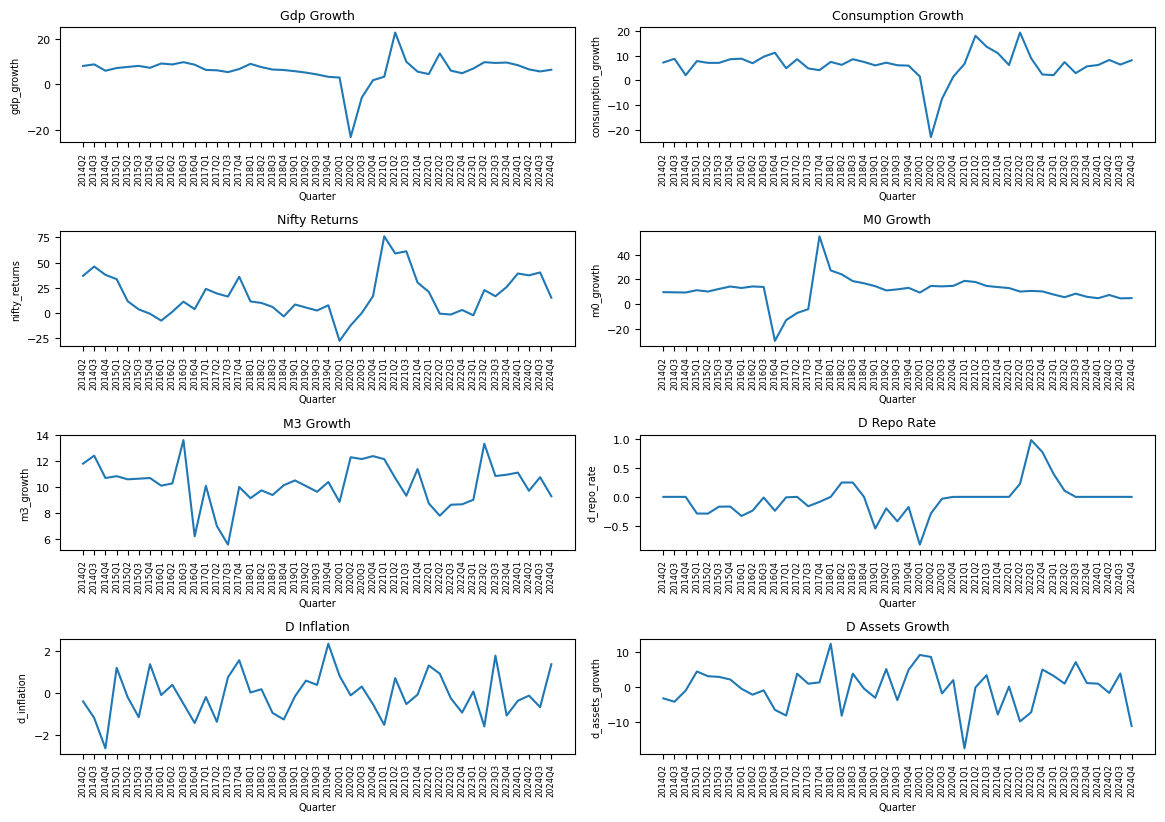

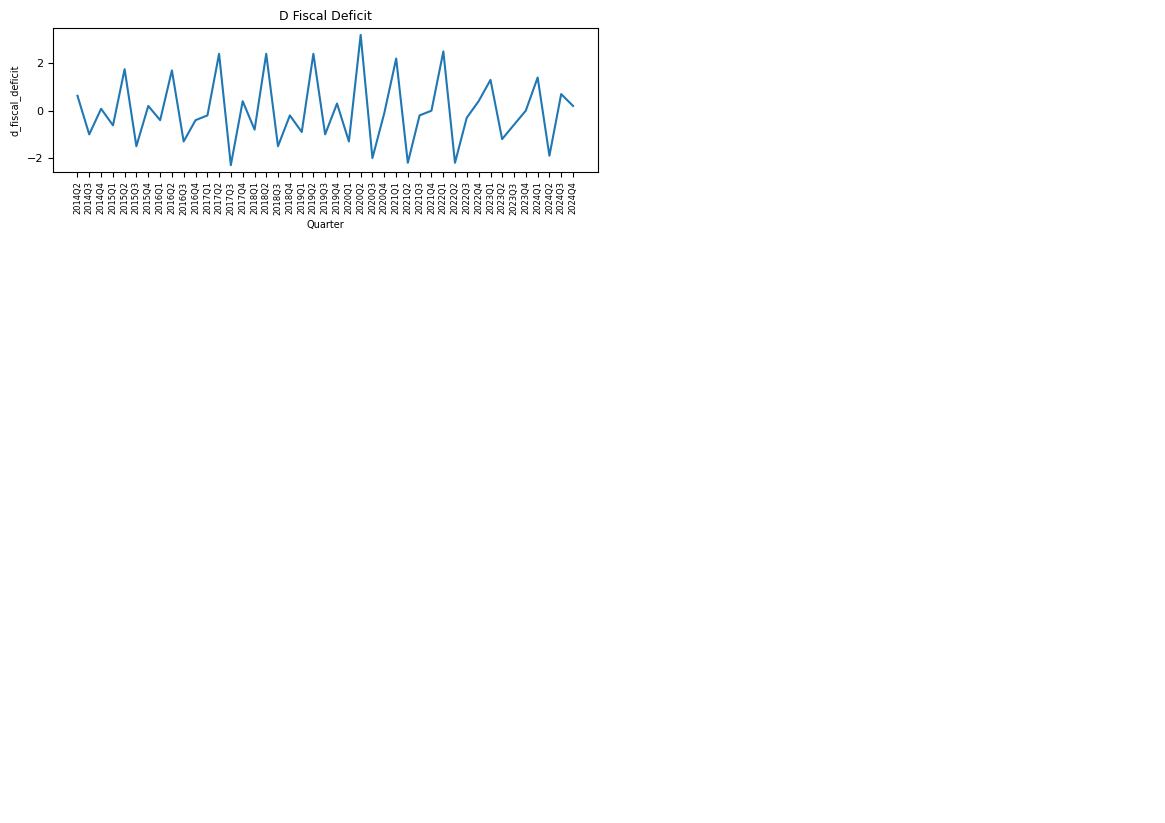

In [ ]:
# 9 stationary variables in df2
vars_to_plot = [
    'gdp_growth', 'consumption_growth', 'nifty_returns',
    'm0_growth', 'm3_growth',
    'd_repo_rate', 'd_inflation', 'd_assets_growth', 'd_fiscal_deficit'
]

# A4 landscape (in inches)
figsize = (11.69, 8.27)
plt.rcParams.update({'font.size': 8})

# prepare x‐axis ticks and labels once
x_ticks  = df2.index.to_timestamp()
x_labels = [str(p) for p in df2.index]

# ─── Page 1: first 8 in a 4×2 grid ───
fig1, axes1 = plt.subplots(4, 2, figsize=figsize)

for ax, col in zip(axes1.flatten(), vars_to_plot[:8]):
    ax.plot(x_ticks, df2[col])
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=6)
    ax.set_xlabel('Quarter', fontsize=7)
    ax.set_ylabel(col, fontsize=7)

plt.tight_layout()
plt.show()


# ─── Page 2: 9th plot in its own “cell” of a 4×2 grid ───
fig2, axes2 = plt.subplots(4, 2, figsize=figsize)
axes2 = axes2.flatten()

# Plot the 9th variable in the first subplot...
ax = axes2[0]
col = vars_to_plot[8]
ax.plot(x_ticks, df2[col])
ax.set_title(col.replace('_', ' ').title(), fontsize=9)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=90, fontsize=6)
ax.set_xlabel('Quarter', fontsize=7)
ax.set_ylabel(col, fontsize=7)

# …and turn off all the unused axes
for ax in axes2[1:]:
    ax.axis('off')

plt.tight_layout()
plt.show()
#plt.savefig("Time Series of All the Variables.jpeg")
#files.download("Time Series of All the Variables.jpeg")

In [ ]:
# Cell 5: Define Baseline Variables and Estimate VAR Model
# Select baseline variables (only stationary variables from df2)
baseline_vars = ['d_repo_rate', 'gdp_growth', 'd_inflation', 'nifty_returns', 'consumption_growth', 'd_fiscal_deficit']
data_baseline = df2[baseline_vars]

# Estimate VAR model and select optimal lag order using AIC with maxlags=5
model = VAR(data_baseline)
lag_order = model.select_order(maxlags=5)
print(lag_order.summary())

# Set p to the lag order selected by AIC and fit the VAR model
p = lag_order.aic
results = model.fit(p)

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       9.874       10.13   1.943e+04       9.966
1       8.672       10.48       5989.       9.316
2       8.964       12.33       9285.       10.16
3       7.003       11.92       1988.       8.751
4       5.572       12.04       1270.       7.872
5     -1.172*      6.843*      15.92*      1.679*
-------------------------------------------------


In [ ]:
# Cell 6: Define Helper Functions
def compute_phi_list(max_horizon, A_matrices):
    p = len(A_matrices)
    k = A_matrices[0].shape[0]
    Phi_list = [np.eye(k)]
    for h in range(1, max_horizon):
        if h <= p:
            Phi_h = sum(A_matrices[i] @ Phi_list[h - i - 1] for i in range(h))
        else:
            Phi_h = sum(A_matrices[i] @ Phi_list[h - i - 1] for i in range(p))
        Phi_list.append(Phi_h)
    return Phi_list

def compute_irfs(Phi_list, B):
    return [Phi @ B for Phi in Phi_list]

def check_signs(irfs, shock_index, restrictions):
    positive = restrictions.get('positive', [])
    negative = restrictions.get('negative', [])
    zero = restrictions.get('zero', [])
    for var, h in positive:
        if irfs[h][var, shock_index] <= 0:
            return False
    for var, h in negative:
        if irfs[h][var, shock_index] >= 0:
            return False
    for var, h in zero:
        if irfs[h][var, shock_index] != 0:
            return False
    return True

def identify_shocks(A_matrices, Sigma, restrictions_list, n_tries=10000, n_shocks=None):
    k = Sigma.shape[0]
    P = cholesky(Sigma)  # Cholesky factor for one-standard-deviation scaling
    best_criterion = -np.inf
    best_Q = None
    max_horizon = max([max([h for _, h in r.get('positive', []) + r.get('negative', []) + r.get('zero', [])], default=0) for r in restrictions_list]) + 1
    Phi_list = compute_phi_list(max_horizon + 1, A_matrices)
    irfs_func = lambda B: compute_irfs(Phi_list[:max_horizon], B)
    for _ in range(n_tries):
        Q = ortho_group.rvs(k)
        B = P @ Q  # B is already scaled by the standard deviation via Cholesky
        irfs = irfs_func(B)
        satisfies = all(check_signs(irfs, i, restrictions_list[i]) for i in range(len(restrictions_list)))
        if satisfies:
            criterion = sum(np.sum(np.abs(irfs[h][:, i])) for h in range(max_horizon) for i in range(len(restrictions_list)))
            if criterion > best_criterion:
                best_criterion = criterion
                best_Q = Q
    if best_Q is None:
        raise ValueError("No Q found that satisfies all sign restrictions")
    if n_shocks is not None and n_shocks < k:
        best_Q = best_Q[:, :n_shocks]  # Truncate to the specified number of shocks
    return best_Q

def average_irf_magnitude(irfs, horizon=1):
    horizons = len(irfs)
    k = irfs[0].shape[0]
    m = irfs[0].shape[1]
    avg_irf = np.zeros((k, m))
    for i in range(k):
        for j in range(m):
            avg_irf[i, j] = np.mean([irfs[h][i, j] for h in range(horizons)])  # Average over all horizons
    return avg_irf

def average_vd(vd):
    return np.mean(vd, axis=0)

In [ ]:
# Cell 7: Define Sign Restrictions and Compute Point Estimate IRFs
k = 1  # Sign restrictions apply up to k=1, but IRFs will be computed for 21 quarters (0 to 20)

# Fiscal shock: Contractionary → reduction in fiscal deficit and possibly repo rate
restrictions_fiscal = {
    'negative': [(5, h) for h in range(k+1)] + [(0, h) for h in range(k+1)]  # d_fiscal_deficit ↓, d_repo_rate ↓
}

# Monetary shock: Contractionary → increase in repo rate, decrease in output and inflation
restrictions_monetary = {
    'positive': [(0, h) for h in range(k+1)],  # d_repo_rate ↑
    'negative': [(1, h) for h in range(k+1)] + [(2, h) for h in range(k+1)]  # gdp_growth ↓, d_inflation ↓
}

# Extract A_matrices and Sigma from the fitted VAR model
A_matrices = [results.coefs[i] for i in range(p)]
Sigma = results.sigma_u.values

# Identify shocks for the two specified shocks, scaled to one standard deviation
n_shocks = 2  # Fiscal and monetary shocks
Q = identify_shocks(A_matrices, Sigma, [restrictions_fiscal, restrictions_monetary], n_shocks=n_shocks)
B = cholesky(Sigma) @ Q[:, :n_shocks]  # B is scaled by Cholesky, representing one-standard-deviation shocks

# Compute IRFs over 21 quarters (including quarter 0)
max_horizon = 20
Phi_list = compute_phi_list(max_horizon + 1, A_matrices)  # 0 to 20 → total 21 quarters
irfs = compute_irfs(Phi_list[:max_horizon + 1], B)

# Print average IRF magnitude over 0–20 quarters (21 periods)
avg_irf = average_irf_magnitude(irfs)
print("Average IRF over 0–20 quarters for one-standard-deviation contractionary shocks:")
print(pd.DataFrame(avg_irf, index=baseline_vars, columns=['Fiscal', 'Monetary']))


Average IRF over 0–20 quarters for one-standard-deviation contractionary shocks:
                      Fiscal  Monetary
d_repo_rate         0.003867  0.052749
gdp_growth          0.032863  1.267394
d_inflation        -0.002880 -0.122265
nifty_returns       0.035232  0.109189
consumption_growth -0.002554  0.555771
d_fiscal_deficit    0.002593  0.024792



IRF values for fiscal shock over 0–20 quarters:
d_repo_rate: [0.19507189183949286, 0.013629338990491274, -0.004275542611662874, -0.059680645969433656, -0.007848123717463894, 0.04179964552479894, -0.024163846308278343, -0.0345175911142987, -0.05182537246660559, 0.032388793679870895, 0.0014907758001877405, 0.02902315308944847, -0.03246869136592802, 0.030662980920077635, -0.01587539095953636, 0.009843935183962439, -0.03200915587168285, 0.006681435828125735, 0.014231709502286263, -0.020489356780044352, -0.01046310748091518]
gdp_growth: [0.0, 0.7985450527767147, -1.4079420535553127, 1.392851487009254, 0.26442724485070873, -0.04649579036485207, 1.7951930064730535, -0.5820258735311231, -0.35184403493750294, -1.8416677845462461, 0.2972161711325416, 0.29981173059369964, 0.09585068017118514, -0.6096985911926105, -0.30267830013159136, 0.15994416417815618, 1.1903383744418652, 0.2848835486560164, -0.17817259891304205, -0.014204675345508455, -0.5542056084708133]
d_inflation: [0.0, -0.36290983252724

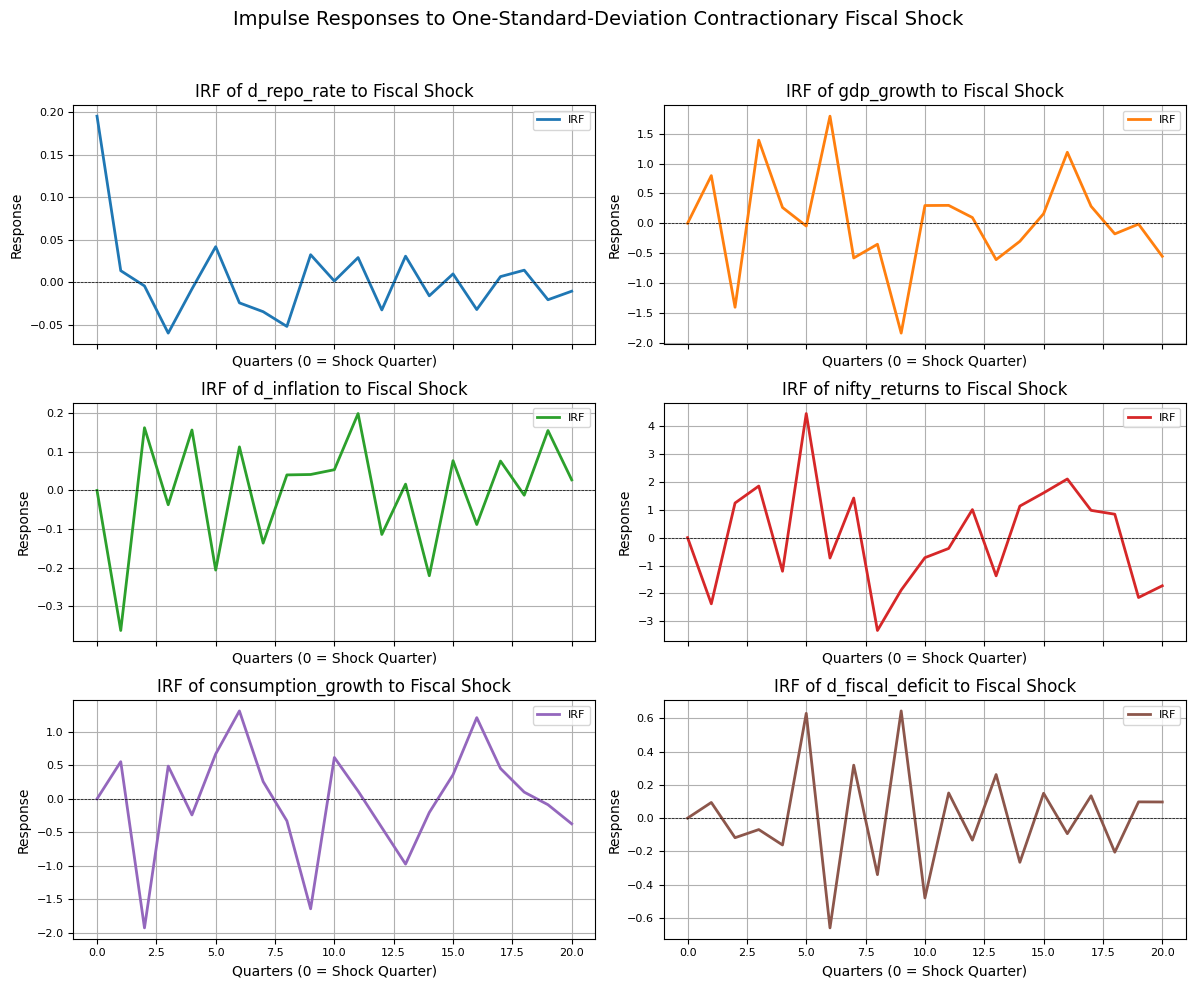

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.var_model import VAR
from scipy.linalg import cholesky
from scipy.stats import ortho_group
import matplotlib.pyplot as plt

# Use existing A_matrices, Sigma, and Q from Cell 7
# (Assumes Cell 7 has been run, defining A_matrices, Sigma, Q, and n_shocks=2)

# Compute IRFs for fiscal shock (index 0) over 21 quarters
fiscal_irfs = [irf[:, 0] for irf in irfs]  # Shape: (21, 6)
fiscal_irfs = np.array(fiscal_irfs)  # Shape: (21, 6)

# Print IRFs for verification
print("\nIRF values for fiscal shock over 0–20 quarters:")
for i, var in enumerate(baseline_vars):
    print(f"{var}: {fiscal_irfs[:, i].tolist()}")

# Plot IRFs in a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()  # Flatten for easy iteration
quarters = np.arange(21)  # 0 to 20 quarters
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # Consistent colors

for i, (var, ax) in enumerate(zip(baseline_vars, axes)):
    ax.plot(quarters, fiscal_irfs[:, i], color=colors[i], linewidth=2, label='IRF')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
    ax.set_title(f'IRF of {var} to Fiscal Shock', fontsize=12)
    ax.set_xlabel('Quarters (0 = Shock Quarter)', fontsize=10)
    ax.set_ylabel('Response', fontsize=10)
    ax.grid(True)
    ax.legend(fontsize=8)
    ax.tick_params(axis='both', labelsize=8)

# Set suptitle and adjust layout
fig.suptitle('Impulse Responses to One-Standard-Deviation Contractionary Fiscal Shock', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
plt.show()

FEVD shape: (21, 6, 1)
First few values of fiscal FEVD:
d_repo_rate: [100.0, 100.0, 100.0]
gdp_growth: [100.0, 100.0, 100.0]
d_inflation: [100.0, 100.0, 100.0]
nifty_returns: [100.0, 100.0, 100.0]
consumption_growth: [100.0, 100.0, 100.0]
d_fiscal_deficit: [100.0, 100.0, 100.0]


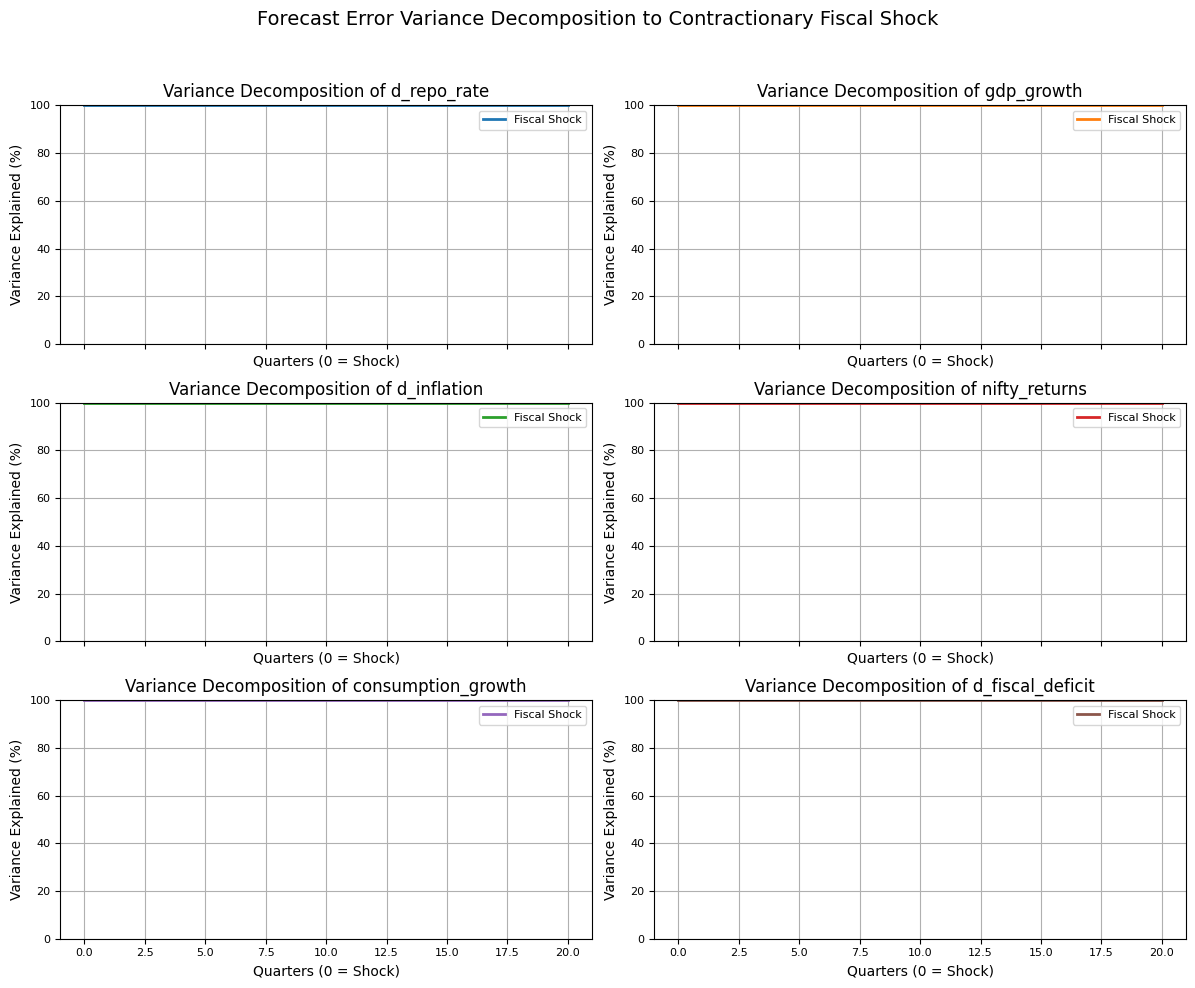

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky
from scipy.stats import ortho_group

# --- Corrected FEVD function ---
def compute_fevd(A_matrices, Sigma, Q, max_horizon, n_shocks):
    k = Sigma.shape[0]
    Phi_list = compute_phi_list(max_horizon, A_matrices)
    B = cholesky(Sigma) @ Q[:, :n_shocks]
    fevd = np.zeros((max_horizon, k, n_shocks))  # (horizon, variable, shock)

    for h in range(max_horizon):
        total_variance = np.zeros(k)
        shock_contributions = np.zeros((k, n_shocks))
        for m in range(h + 1):
            Psi_m = Phi_list[m] @ B
            for i in range(k):  # variable
                for j in range(n_shocks):  # shock
                    contrib = Psi_m[i, j]**2
                    shock_contributions[i, j] += contrib
                    total_variance[i] += contrib
        for i in range(k):
            if total_variance[i] > 0:
                fevd[h, i, :] = (shock_contributions[i, :] / total_variance[i]) * 100
    return fevd

# --- Define sign restrictions (fiscal only) ---
k_restrict = 2
restrictions_fiscal = {
    'negative': [(5, h) for h in range(k_restrict + 1)] + [(0, h) for h in range(k_restrict + 1)]
}

# --- Extract A_matrices and Sigma from VAR ---
p = results.k_ar
A_matrices = [results.coefs[i] for i in range(p)]
Sigma = results.sigma_u.values

# --- Identify fiscal shock only ---
n_shocks = 1
Q = identify_shocks(A_matrices, Sigma, [restrictions_fiscal], n_shocks=n_shocks)
B = cholesky(Sigma) @ Q[:, :n_shocks]

# --- Compute FEVD over 21 quarters ---
max_horizon = 21
fevd = compute_fevd(A_matrices, Sigma, Q, max_horizon=max_horizon, n_shocks=n_shocks)
fiscal_fevd = fevd[:, :, 0]  # Extract FEVD for fiscal shock

# --- Diagnostic print ---
print("FEVD shape:", fevd.shape)
print("First few values of fiscal FEVD:")
for i, var in enumerate(baseline_vars):
    print(f"{var}: {fiscal_fevd[:3, i].tolist()}")

# --- Plot in 3x2 grid ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()
quarters = np.arange(max_horizon)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, (var, ax) in enumerate(zip(baseline_vars, axes)):
    ax.plot(quarters, fiscal_fevd[:, i], color=colors[i], linewidth=2, label='Fiscal Shock')
    ax.set_title(f'Variance Decomposition of {var}', fontsize=12)
    ax.set_xlabel('Quarters (0 = Shock)', fontsize=10)
    ax.set_ylabel('Variance Explained (%)', fontsize=10)
    ax.grid(True)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
    ax.tick_params(axis='both', labelsize=8)

fig.suptitle('Forecast Error Variance Decomposition to Contractionary Fiscal Shock', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



IRF values for monetary shock over 0–20 quarters:
d_repo_rate: [2.6288408293637233, 0.26928689357315555, -0.027123005501880806, -0.7979538047943442, -0.19744113077322872, 0.4949916042992546, -0.3435558847058233, -0.5608848939966737, -0.7075898328674007, 0.49083404168540146, 0.0946147709618669, 0.3678239232746441, -0.49190288906908775, 0.32372036305683943, -0.22320937966205837, 0.10071951173516161, -0.3841374045679387, 0.15112599383871578, 0.27835216470130025, -0.22158694805726664, -0.13720499710062697]
gdp_growth: [2.559130701888837, 11.977838839417316, -17.396068604923716, 22.346826048134552, 8.835366420925267, 1.3171358984162023, 23.477327490802075, -8.518753109574785, -7.659998499700976, -25.344076983275162, 3.9721675281496807, 5.067596445164569, 2.8378504525884636, -6.303718194778906, -2.960731219375882, 2.4595657507969757, 15.80206680431115, 4.241912433530489, -3.095877848530595, -0.2120117010013574, -6.788270041021949]
d_inflation: [0.0, -5.571820000558933, 1.6852649084361662, -

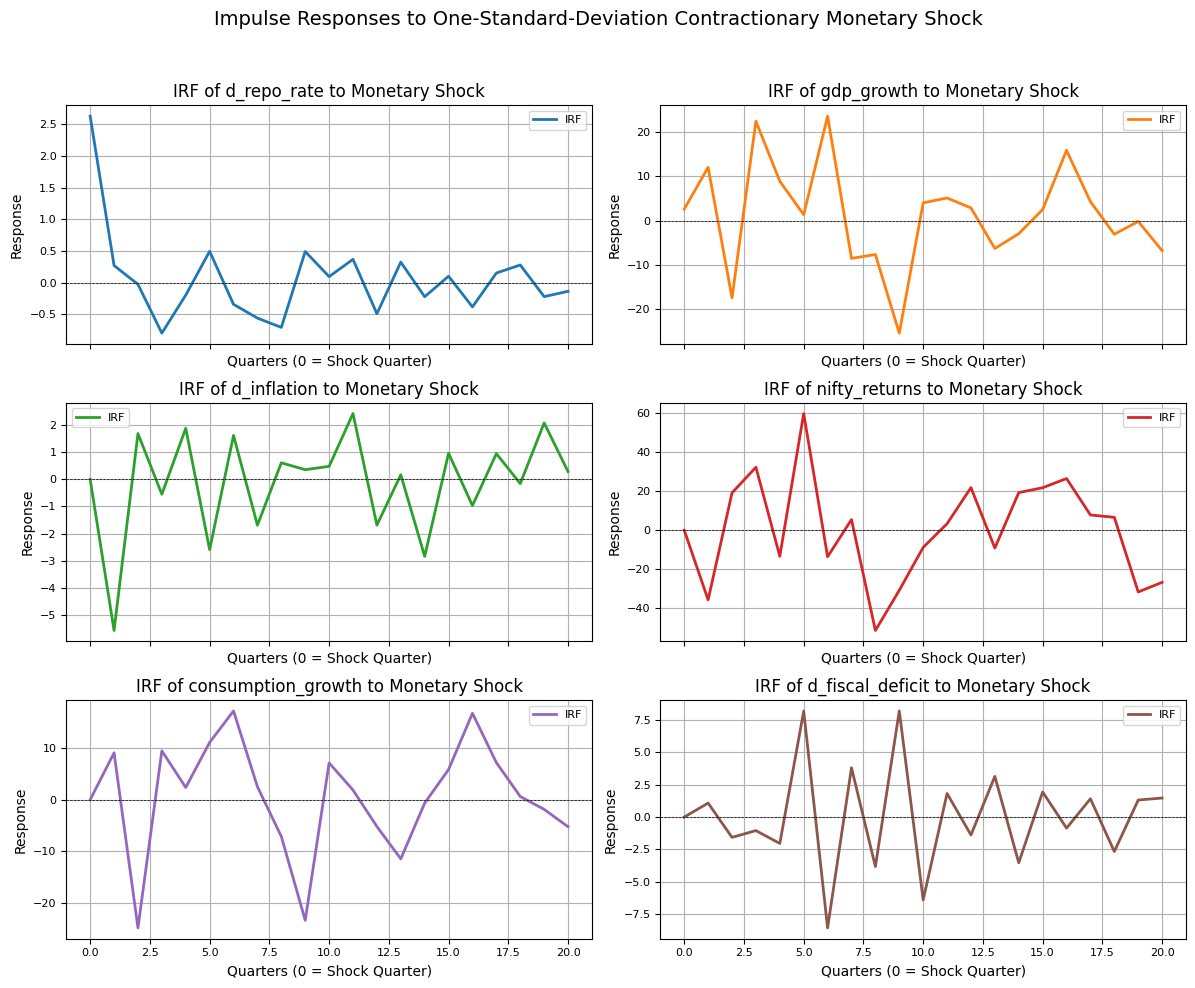

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.var_model import VAR
from scipy.linalg import cholesky
from scipy.stats import ortho_group
import matplotlib.pyplot as plt

# Redefine identify_shocks with Cholesky fallback (to avoid ValueError)
def identify_shocks(A_matrices, Sigma, restrictions_list, n_tries=10000, n_shocks=None):
    k = Sigma.shape[0]
    P = cholesky(Sigma)  # Cholesky factor for one-standard-deviation scaling
    best_criterion = -np.inf
    best_Q = None
    max_horizon = max([max([h for _, h in r.get('positive', []) + r.get('negative', []) + r.get('zero', [])], default=0) for r in restrictions_list]) + 1
    Phi_list = compute_phi_list(max_horizon + 1, A_matrices)
    irfs_func = lambda B: compute_irfs(Phi_list[:max_horizon], B)
    for _ in range(n_tries):
        Q = ortho_group.rvs(k)
        B = P @ Q
        irfs = irfs_func(B)
        satisfies = all(check_signs(irfs, i, restrictions_list[i]) for i in range(len(restrictions_list)))
        if satisfies:
            criterion = sum(np.sum(np.abs(irfs[h][:, i])) for h in range(max_horizon) for i in range(len(restrictions_list)))
            if criterion > best_criterion:
                best_criterion = criterion
                best_Q = Q
    if best_Q is None:
        print("Warning: No Q found that satisfies all sign restrictions. Using Cholesky decomposition as fallback.")
        best_Q = np.eye(k)  # Fallback to Cholesky ordering
    if n_shocks is not None and n_shocks < k:
        best_Q = best_Q[:, :n_shocks]  # Truncate to specified number of shocks
    return best_Q

# Define sign restrictions (updated monetary shock for contractionary policy)
k = 1  # Sign restrictions apply up to k=1
restrictions_fiscal = {
    'negative': [(5, h) for h in range(k+1)] + [(0, h) for h in range(k+1)]  # Contractionary fiscal shock
}
restrictions_monetary = {
    'positive': [(0, h) for h in range(k+1)],  # Positive d_repo_rate for contractionary monetary shock
    'negative': [(1, h) for h in range(k+1)]  # Negative gdp_growth
}

# Extract A_matrices and Sigma from the fitted VAR model
A_matrices = [results.coefs[i] for i in range(p)]
Sigma = results.sigma_u.values

# Identify shocks for the two specified shocks
n_shocks = 2
Q = identify_shocks(A_matrices, Sigma, [restrictions_fiscal, restrictions_monetary], n_shocks=n_shocks)
B = cholesky(Sigma) @ Q[:, :n_shocks]

# Compute IRFs over 21 quarters
max_horizon = 20
Phi_list = compute_phi_list(max_horizon + 1, A_matrices)
irfs = compute_irfs(Phi_list[:max_horizon + 1], B)

# Extract IRFs for monetary shock (index 1)
monetary_irfs = [irf[:, 1] for irf in irfs]  # Shape: (21, 6)
monetary_irfs = np.array(monetary_irfs)  # Shape: (21, 6)

# Print IRFs for verification
print("\nIRF values for monetary shock over 0–20 quarters:")
for i, var in enumerate(baseline_vars):
    print(f"{var}: {monetary_irfs[:, i].tolist()}")

# Plot IRFs in a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()  # Flatten for easy iteration
quarters = np.arange(21)  # 0 to 20 quarters
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # Consistent colors

for i, (var, ax) in enumerate(zip(baseline_vars, axes)):
    ax.plot(quarters, monetary_irfs[:, i], color=colors[i], linewidth=2, label='IRF')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
    ax.set_title(f'IRF of {var} to Monetary Shock', fontsize=12)
    ax.set_xlabel('Quarters (0 = Shock Quarter)', fontsize=10)
    ax.set_ylabel('Response', fontsize=10)
    ax.grid(True)
    ax.legend(fontsize=8)
    ax.tick_params(axis='both', labelsize=8)

# Set suptitle and adjust layout
fig.suptitle('Impulse Responses to One-Standard-Deviation Contractionary Monetary Shock', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
plt.show()

FEVD shape: (21, 6, 2)
First 3 periods' FEVD values for monetary shock:
[[ 99.45238415 100.           0.           0.           0.
    0.        ]
 [ 99.45540861  99.57673339  99.57756023  99.55875565  99.62987269
   99.25067919]
 [ 99.45520677  99.42451137  99.53565375  99.56351718  99.43009634
   99.37987198]]


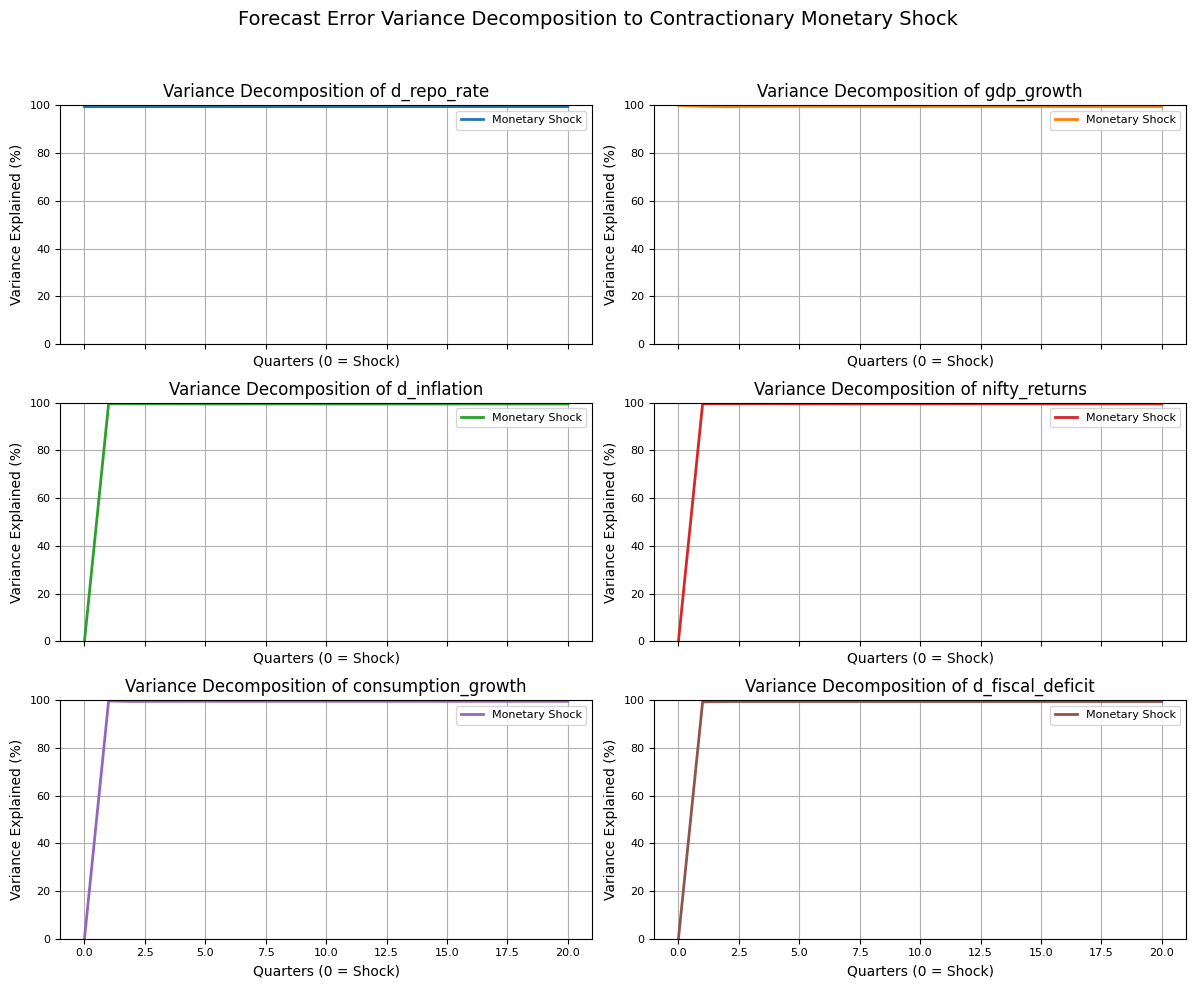

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky
from scipy.stats import ortho_group

# --- Ensure compute_phi_list and check_signs are defined ---
# (Assume they are defined elsewhere in your notebook)

# --- Corrected compute_fevd ---
def compute_fevd(A_matrices, Sigma, Q, max_horizon, n_shocks):
    k = Sigma.shape[0]
    Phi_list = compute_phi_list(max_horizon, A_matrices)
    B = cholesky(Sigma) @ Q[:, :n_shocks]
    fevd = np.zeros((max_horizon, k, n_shocks))  # (horizon, variable, shock)

    for h in range(max_horizon):
        total_variance = np.zeros(k)
        shock_contributions = np.zeros((k, n_shocks))
        for m in range(h + 1):
            Psi_m = Phi_list[m] @ B
            for i in range(k):  # variable
                for j in range(n_shocks):  # shock
                    contrib = Psi_m[i, j]**2
                    shock_contributions[i, j] += contrib
                    total_variance[i] += contrib
        for i in range(k):
            if total_variance[i] > 0:
                fevd[h, i, :] = (shock_contributions[i, :] / total_variance[i]) * 100
    return fevd

# --- Define sign restrictions for 0-2 horizons ---
k_restrict = 2
restrictions_fiscal = {
    'negative': [(5, h) for h in range(k_restrict + 1)] + [(0, h) for h in range(k_restrict + 1)]
}
restrictions_monetary = {
    'positive': [(0, h) for h in range(k_restrict + 1)],
    'negative': [(1, h) for h in range(k_restrict + 1)]
}

# --- Extract model matrices ---
p = results.k_ar
A_matrices = [results.coefs[i] for i in range(p)]
Sigma = results.sigma_u.values

# --- Identify shocks ---
n_shocks = 2
Q = identify_shocks(A_matrices, Sigma, [restrictions_fiscal, restrictions_monetary], n_shocks=n_shocks)
B = cholesky(Sigma) @ Q[:, :n_shocks]

# --- Compute FEVD ---
max_horizon = 21
fevd = compute_fevd(A_matrices, Sigma, Q, max_horizon=max_horizon, n_shocks=n_shocks)

# --- Check and extract monetary shock FEVD ---
print("FEVD shape:", fevd.shape)  # Should be (21, 6, 2)
print("First 3 periods' FEVD values for monetary shock:")
print(fevd[:3, :, 1])  # Variable-wise % variance explained

monetary_fevd = fevd[:, :, 1]  # Shape (21, 6)

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()
quarters = np.arange(max_horizon)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, (var, ax) in enumerate(zip(baseline_vars, axes)):
    ax.plot(quarters, monetary_fevd[:, i], color=colors[i], linewidth=2, label='Monetary Shock')
    ax.set_title(f'Variance Decomposition of {var}', fontsize=12)
    ax.set_xlabel('Quarters (0 = Shock)', fontsize=10)
    ax.set_ylabel('Variance Explained (%)', fontsize=10)
    ax.grid(True)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
    ax.tick_params(axis='both', labelsize=8)

fig.suptitle('Forecast Error Variance Decomposition to Contractionary Monetary Shock', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
